# 2. Polarization: E and B modes, leakage and purification

CMB polarization is a spin-2 field, $Q \pm iU$. On the full sky it splits into curl-free **E** and
divergence-free **B** modes; on a masked sky the split is ambiguous near the mask edges, and the
large E signal leaks into B. This notebook shows

1. how to build spin-0 (T) and spin-2 (Q, U) fields and measure all of $TT, TE, TB, EE, EB, BB$,
2. why the *variance* of the B-mode estimate is dominated by E-to-B leakage on a small patch,
3. how **B-mode purification** (`purify_b=True`, Smith 2006) removes it.

In [1]:
import os
os.environ.setdefault("JAX_ENABLE_X64", "1")   # NaMaster-level double precision; set before importing JAX

import time
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import jax
import gmaster as nmt

print("GMaster", nmt.__version__, "| JAX", jax.__version__, "| device:", jax.devices()[0].device_kind)

GMaster 1.0.0 | JAX 0.10.0 | device: NVIDIA RTX PRO 6000 Blackwell Workstation Edition


In [2]:
import camb

def camb_spectra(lmax, r=0.0):
    """Lensed CMB C_ell in muK^2 (TT, EE, BB, TE) for a Planck-2018-like cosmology, ell = 0..lmax."""
    pars = camb.set_params(H0=67.4, ombh2=0.0224, omch2=0.120, mnu=0.06, omk=0, tau=0.054,
                           As=2.1e-9, ns=0.965, r=r, lmax=lmax + 500, WantTensors=r > 0)
    res = camb.get_results(pars)
    cl = res.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True, lmax=lmax)["total"]
    return {k: cl[:, i] for i, k in enumerate(["TT", "EE", "BB", "TE"])}

nside = 256
lmax = 3 * nside - 1
ell = np.arange(lmax + 1)
cl = camb_spectra(lmax)
np.random.seed(42)
T, Q, U = hp.synfast([cl["TT"], cl["EE"], cl["BB"], cl["TE"]], nside, lmax=lmax, new=True, pol=True)

theta, phi = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))
binary = (np.abs(90.0 - np.degrees(theta)) > 20.0).astype(float)
mask = np.asarray(nmt.mask_apodization(binary, 2.0, apotype="C1"))
print(f"f_sky = {mask.mean():.3f}")

f_sky = 0.643


## Spin-0 and spin-2 fields

A field built from two maps is spin 2 (you can also pass `spin=2` explicitly). Its harmonic
coefficients are $(a^E_{\ell m}, a^B_{\ell m})$. The cross-spectra of two fields come in the
order NaMaster uses:

| fields | spectra |
|---|---|
| spin 0 x spin 0 | `[TT]` |
| spin 0 x spin 2 | `[TE, TB]` |
| spin 2 x spin 2 | `[EE, EB, BE, BB]` |

Each pair of fields has its own coupling matrix, hence its own workspace.

In [3]:
f_T = nmt.NmtField(mask, [T])
f_P = nmt.NmtField(mask, [Q, U])
bins = nmt.NmtBin.from_nside_linear(nside, 16)
ell_eff = np.asarray(bins.get_effective_ells())

def decoupled(fa, fb):
    w = nmt.NmtWorkspace.from_fields(fa, fb, bins)
    return w, np.asarray(w.decouple_cell(nmt.compute_coupled_cell(fa, fb)))

w00, c00 = decoupled(f_T, f_T)
w02, c02 = decoupled(f_T, f_P)
w22, c22 = decoupled(f_P, f_P)
print("TT", c00.shape, "| TE,TB", c02.shape, "| EE,EB,BE,BB", c22.shape)

TT (1, 47) | TE,TB (2, 47) | EE,EB,BE,BB (4, 47)


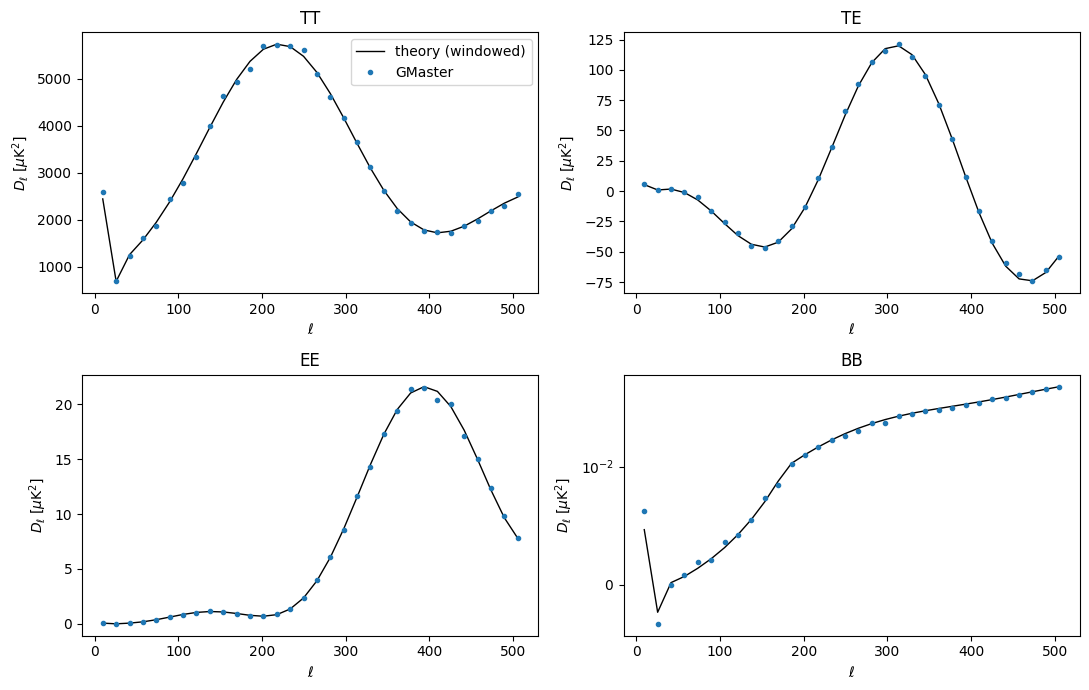

In [4]:
def binned_theory(w, cls):
    """Theory convolved with the bandpower windows; `cls` lists the input spectra in field order."""
    win = np.asarray(w.get_bandpower_windows())
    return np.einsum("ibjl,jl->ib", win, np.array(cls))

zero = np.zeros_like(cl["TT"])
th00 = binned_theory(w00, [cl["TT"]])
th02 = binned_theory(w02, [cl["TE"], zero])
th22 = binned_theory(w22, [cl["EE"], zero, zero, cl["BB"]])

fac = ell_eff * (ell_eff + 1) / (2 * np.pi)
keep = ell_eff < 2 * nside          # HEALPix quadrature is accurate below ~2 nside
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, data, theory) in zip(axes.flat, [("TT", c00[0], th00[0]), ("TE", c02[0], th02[0]),
                                                 ("EE", c22[0], th22[0]), ("BB", c22[3], th22[3])]):
    ax.plot(ell_eff[keep], (fac * theory)[keep], "k-", lw=1, label="theory (windowed)")
    ax.plot(ell_eff[keep], (fac * data)[keep], "o", ms=3, label="GMaster")
    ax.set_title(name); ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$D_\ell$ [$\mu$K$^2$]")
axes[0, 0].legend()
axes[1, 1].set_yscale("symlog", linthresh=1e-2)
plt.tight_layout()

The large-scale structure of TT, TE and EE is recovered. BB is the lensing signal, a few
$10^{-2}\,\mu{\rm K}^2$: tiny compared with EE, and its estimate is noisy. The next section shows
where that noise comes from.

## E-to-B leakage on a small patch

We now observe a $15^\circ$ circular patch, as a ground-based B-mode experiment would, and simulate
skies with **no B modes at all** ($C_\ell^{BB}=0$). Any B power we measure is leakage. We compare
the scatter of the BB estimate over 20 simulations for

* standard spin-2 fields, and
* **pure-B** fields (`purify_b=True`), which project out the ambiguous modes using derivatives of
  the mask. Purification needs a mask that is smooth to at least second derivative, so we use the
  C2 apodization with a large (5 degree) scale.

20 simulations x 2 estimators in 29.5 s


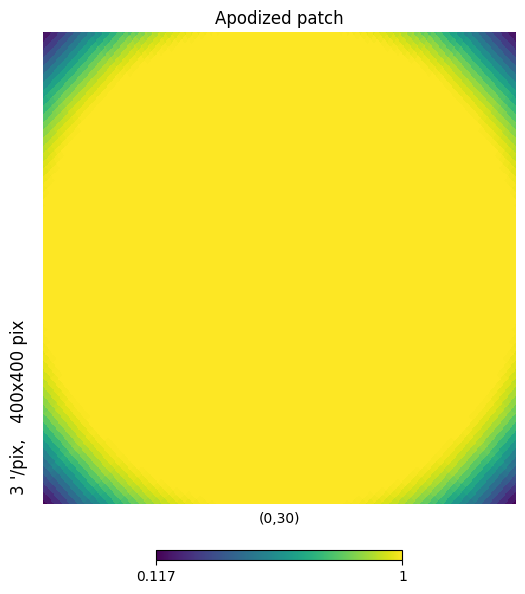

In [5]:
center = hp.ang2vec(np.radians(60.0), 0.0)
patch = np.zeros(hp.nside2npix(nside))
patch[hp.query_disc(nside, center, np.radians(15.0))] = 1.0
patch_mask = np.asarray(nmt.mask_apodization(patch, 5.0, apotype="C2"))
hp.gnomview(patch_mask, rot=(0, 30), reso=3, xsize=400, title="Apodized patch", cmap="viridis")

bins_patch = nmt.NmtBin.from_nside_linear(nside, 32)
ell_patch = np.asarray(bins_patch.get_effective_ells())
cl_no_B = [cl["TT"], cl["EE"], np.zeros_like(cl["BB"]), cl["TE"]]

def one_sim(seed):
    np.random.seed(seed)
    _, q, u = hp.synfast(cl_no_B, nside, lmax=lmax, new=True, pol=True)
    return q, u

q, u = one_sim(0)
w_std = nmt.NmtWorkspace.from_fields(nmt.NmtField(patch_mask, [q, u]), nmt.NmtField(patch_mask, [q, u]), bins_patch)
f_pure = nmt.NmtField(patch_mask, [q, u], purify_b=True)
w_pure = nmt.NmtWorkspace.from_fields(f_pure, f_pure, bins_patch)

bb_std, bb_pure = [], []
t0 = time.perf_counter()
for seed in range(20):
    q, u = one_sim(seed)
    fs = nmt.NmtField(patch_mask, [q, u])
    fp = nmt.NmtField(patch_mask, [q, u], purify_b=True)
    bb_std.append(np.asarray(w_std.decouple_cell(nmt.compute_coupled_cell(fs, fs)))[3])
    bb_pure.append(np.asarray(w_pure.decouple_cell(nmt.compute_coupled_cell(fp, fp)))[3])
print(f"20 simulations x 2 estimators in {time.perf_counter() - t0:.1f} s")

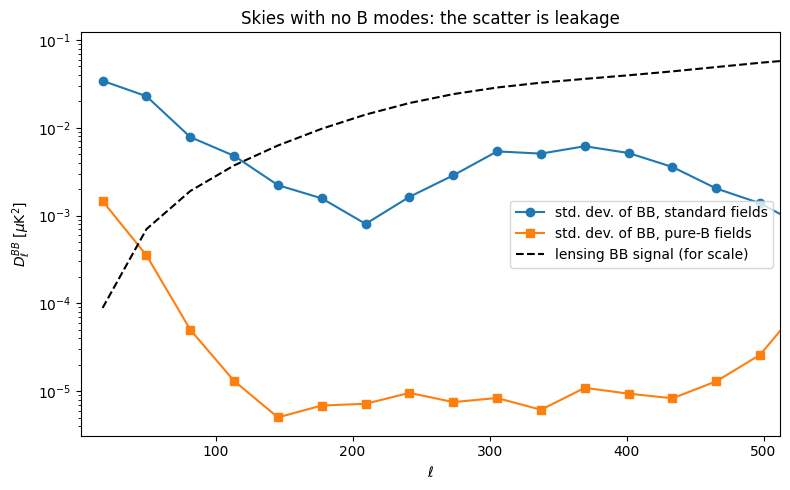

In [6]:
fac = ell_patch * (ell_patch + 1) / (2 * np.pi)
lens_bb = np.asarray(bins_patch.bin_cell(cl["BB"][None]))[0]
plt.figure(figsize=(8, 5))
plt.semilogy(ell_patch, fac * np.std(bb_std, axis=0), "o-", label="std. dev. of BB, standard fields")
plt.semilogy(ell_patch, fac * np.std(bb_pure, axis=0), "s-", label="std. dev. of BB, pure-B fields")
plt.semilogy(ell_patch, fac * lens_bb, "k--", label="lensing BB signal (for scale)")
plt.xlabel(r"$\ell$"); plt.ylabel(r"$D_\ell^{BB}$ [$\mu$K$^2$]"); plt.xlim(2, 2 * nside)
plt.legend(); plt.title("Skies with no B modes: the scatter is leakage")
plt.tight_layout()

Without purification the leaked E power swamps the lensing B-mode signal by orders of magnitude on
a patch this size. With `purify_b=True` the scatter drops to near the level set by the (zero) input.
The mean of either estimator is unbiased; purification reduces the **variance**.

The same workspace is reused for every simulation. Only the fields change, which is how Monte Carlo
pipelines should be structured (tutorial 3).